In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [3]:
df = pd.read_csv('C:\\Users\\tranu\\Desktop\\SMART RAILWAY RESOURCE PLANNING\\data\\railway_dataset.csv')
df.head()

,Train_ID,Train_Name,Source,Destination,Route,Date,Departure_Time,Day_of_Week,Is_Weekend,Is_Holiday,Platform_Number,Num_Coaches,Seat_Capacity,Passenger_Count,Seat_Occupancy_Percent,Delay_Minutes,Weather,Season,Demand_Level
0,TR457,Garib Rath,Bangalore,Nagpur,Bangalore-Nagpur,04-05-2025,07:42,Sunday,1,0,4,16,1152,811,70.40,32,Clear,Monsoon,Medium
1,TR636,Rajdhani Express,Chennai,Nagpur,Chennai-Nagpur,26-12-2025,01:40,Friday,0,0,4,18,1296,1250,96.45,10,Clear,Summer,High
2,TR307,Duronto Express,Kolkata,Lucknow,Kolkata-Lucknow,06-01-2025,16:27,Monday,0,0,5,10,720,361,50.14,11,Fog,Winter,Low
3,TR903,Shatabdi Express,Hyderabad,Lucknow,Hyderabad-Lucknow,18-08-2025,18:13,Monday,0,0,1,9,648,337,52.01,0,Clear,Monsoon,Low
4,TR379,Shatabdi Express,Chennai,Vizag,Chennai-Vizag,09-01-2025,00:28,Thursday,0,0,2,9,648,666,102.78,14,Cloudy,Monsoon,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Train_ID                500 non-null    object 
 1   Train_Name              500 non-null    object 
 2   Source                  500 non-null    object 
 3   Destination             500 non-null    object 
 4   Route                   500 non-null    object 
 5   Date                    500 non-null    object 
 6   Departure_Time          500 non-null    object 
 7   Day_of_Week             500 non-null    object 
 8   Is_Weekend              500 non-null    int64  
 9   Is_Holiday              500 non-null    int64  
 10  Platform_Number         500 non-null    int64  
 11  Num_Coaches             500 non-null    int64  
 12  Seat_Capacity           500 non-null    int64  
 13  Passenger_Count         500 non-null    int64  
 14  Seat_Occupancy_Percent  500 non-null    fl

In [5]:
df.describe()

,Is_Weekend,Is_Holiday,Platform_Number,Num_Coaches,Seat_Capacity,Passenger_Count,Seat_Occupancy_Percent,Delay_Minutes
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000,500.00000,500.00000
mean,0.318000,0.108000,5.474000,13.966000,1005.55200,802.48000,79.79942,11.67600
std,0.466166,0.310691,2.825117,3.760469,270.75376,281.87572,17.63196,11.30835
min,0.000000,0.000000,1.000000,8.000000,576.00000,288.00000,50.00000,0.00000
25%,0.000000,0.000000,3.000000,11.000000,792.00000,599.75000,63.89500,0.00000
50%,0.000000,0.000000,6.000000,14.000000,1008.00000,758.00000,80.88000,10.00000
75%,1.000000,0.000000,8.000000,17.000000,1224.00000,982.50000,95.22000,19.00000
max,1.000000,1.000000,10.000000,20.000000,1440.00000,1561.00000,109.92000,61.00000


In [6]:
df.isnull().sum()

Train_ID                  0
Train_Name                0
Source                    0
Destination               0
Route                     0
Date                      0
Departure_Time            0
Day_of_Week               0
Is_Weekend                0
Is_Holiday                0
Platform_Number           0
Num_Coaches               0
Seat_Capacity             0
Passenger_Count           0
Seat_Occupancy_Percent    0
Delay_Minutes             0
Weather                   0
Season                    0
Demand_Level              0
dtype: int64

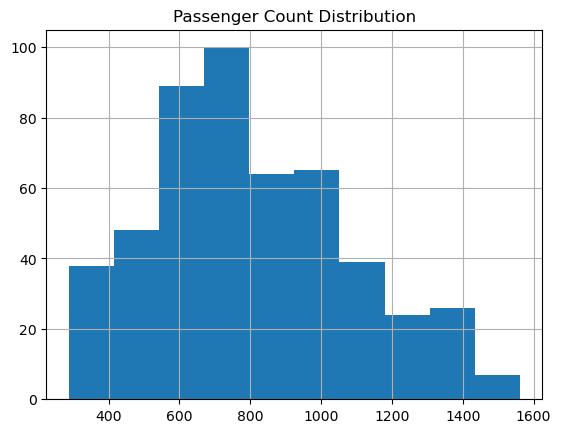

In [8]:
# EDA
plt.figure()
df['Passenger_Count'].hist()
plt.title('Passenger Count Distribution')
plt.show()

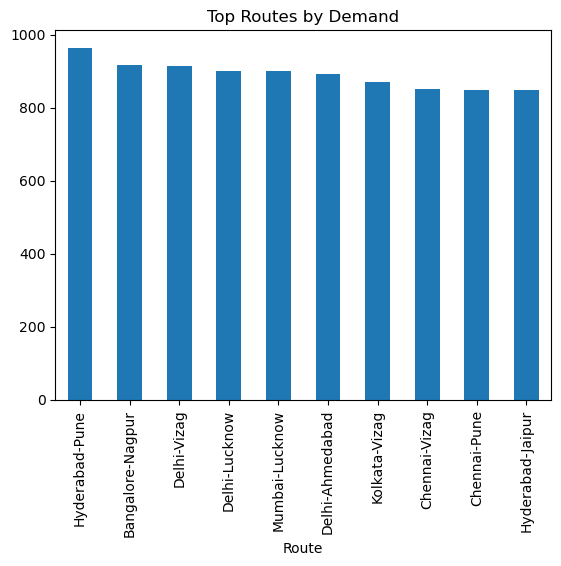

In [9]:
route_demand = df.groupby('Route')['Passenger_Count'].mean().sort_values(ascending=False)
plt.figure()
route_demand.head(10).plot(kind='bar')
plt.title('Top Routes by Demand')
plt.show()

In [11]:
# Feature Engineering
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Hour'] = pd.to_datetime(df['Departure_Time']).dt.hour
df_model = df[['Num_Coaches','Platform_Number','Is_Weekend','Is_Holiday','Month','Hour','Passenger_Count']]

C:\Users\tranu\AppData\Local\Temp\ipykernel_6744\3122591998.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Departure_Time']).dt.hour


In [12]:
# splitting the dataset
X = df_model.drop('Passenger_Count', axis=1)
y = df_model['Passenger_Count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(400, 6) (100, 6)


In [13]:
# model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred[:10]

array([ 824.25      , 1004.6       ,  733.26333333,  356.65      ,
       1125.22      ,  726.53      ,  780.75      ,  833.6       ,
        535.56      ,  854.24      ])

In [14]:
# model evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 152.04299333333333
MSE: 34619.848164920004
RMSE: 186.06409692608622
R2 Score: 0.49096853033937693


In [15]:
# saving the model
joblib.dump(model, 'railway_demand_model.pkl')
print('Model saved successfully')

Model saved successfully
